In [2]:
# ── All the tools we need
import os                              # for navigating folders
import zipfile                         # for unzipping files
import numpy as np                     # for number crunching
import pandas as pd                    # for data tables
import matplotlib.pyplot as plt        # for drawing charts
import matplotlib.patches as mpatches
import seaborn as sns                  # for prettier charts

from PIL import Image                  # for opening/resizing images
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Fix random seeds so results are consistent every run
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported!
TensorFlow version: 2.20.0


In [3]:
# ── Upload the zip file from your computer
from google.colab import files
print("📂 Please upload the dataset ZIP file...")
uploaded = files.upload()

# ── Get the name of the uploaded zip file (automatically detected)
zip_filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {zip_filename}")

📂 Please upload the dataset ZIP file...


Saving ai_project_synthetic_datasets-20260517T074055Z-3-001.zip to ai_project_synthetic_datasets-20260517T074055Z-3-001.zip

✅ Uploaded: ai_project_synthetic_datasets-20260517T074055Z-3-001.zip


In [5]:
# ── Extract only the Part 2 image folders from the ZIP
print("📦 Extracting Part 2 images...")

with zipfile.ZipFile(zip_filename, 'r') as z:
    # List all files in the zip
    all_files = z.namelist()
    # Filter only files that belong to Part 2 images (skip .DS_Store)
    part2_files = [
        f for f in all_files
        if 'part_2_cnn_computer_vision/images/' in f
        and not f.endswith('/')
        and '.DS_Store' not in f
        and f.endswith('.png')
    ]
    # Also extract the labels CSV
    labels_files = [f for f in all_files if 'part_2_cnn_computer_vision/labels.csv' in f]

    for f in part2_files + labels_files:
        z.extract(f)

print(f"✅ Extracted {len(part2_files)} images!")

# ── Set the base directory for our images
BASE_DIR = 'ai_project_synthetic_datasets/part_2_cnn_computer_vision/images'
CLASSES = ['normal', 'scratch', 'dent', 'stain']

print(f"\nImage folders found:")
for cls in CLASSES:
    count = len(os.listdir(f'{BASE_DIR}/{cls}'))
    print(f"  {cls}: {count} images")

📦 Extracting Part 2 images...
✅ Extracted 480 images!

Image folders found:
  normal: 120 images
  scratch: 120 images
  dent: 120 images
  stain: 120 images


In [6]:
# ── Count images per class and check for imbalance
print("📸 Dataset Summary:")
print("-" * 35)
class_counts = {}
total = 0
for cls in CLASSES:
    imgs = [f for f in os.listdir(f'{BASE_DIR}/{cls}') if f.endswith('.png')]
    class_counts[cls] = len(imgs)
    total += len(imgs)
    print(f"  {cls:10s}: {len(imgs)} images")

print("-" * 35)
print(f"  {'TOTAL':10s}: {total} images")
print(f"  Number of classes: {len(CLASSES)}")

# ── Check one image to get dimensions
sample_path = f"{BASE_DIR}/{CLASSES[0]}/{os.listdir(f'{BASE_DIR}/{CLASSES[0]}')[0]}"
sample_img = Image.open(sample_path)
print(f"  Image size: {sample_img.size[0]}x{sample_img.size[1]} pixels, Mode: {sample_img.mode}")

# ── Check for class imbalance
print("\n📊 Class Balance Check:")
min_c = min(class_counts.values())
max_c = max(class_counts.values())
if max_c - min_c <= 5:
    print("  ✅ Dataset is BALANCED — all classes have roughly equal images.")
else:
    print("  ⚠️  Dataset is IMBALANCED — some classes have more images than others.")

📸 Dataset Summary:
-----------------------------------
  normal    : 120 images
  scratch   : 120 images
  dent      : 120 images
  stain     : 120 images
-----------------------------------
  TOTAL     : 480 images
  Number of classes: 4
  Image size: 96x96 pixels, Mode: RGB

📊 Class Balance Check:
  ✅ Dataset is BALANCED — all classes have roughly equal images.


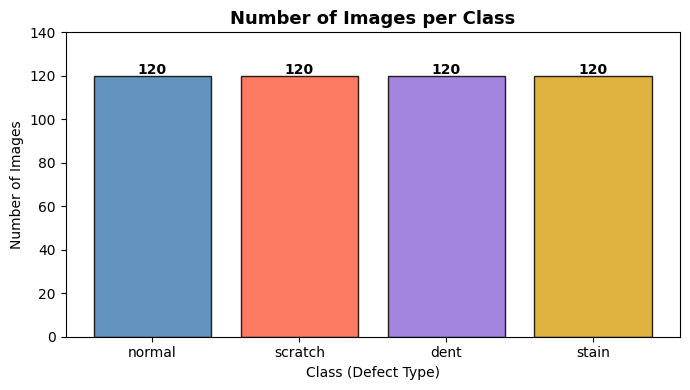

✅ Saved: class_distribution.png


In [7]:
# ── Bar chart of class distribution
plt.figure(figsize=(7, 4))
colors = ['steelblue', 'tomato', 'mediumpurple', 'goldenrod']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.title('Number of Images per Class', fontsize=13, fontweight='bold')
plt.xlabel('Class (Defect Type)')
plt.ylabel('Number of Images')
plt.ylim(0, max(class_counts.values()) + 20)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✅ Saved: class_distribution.png")

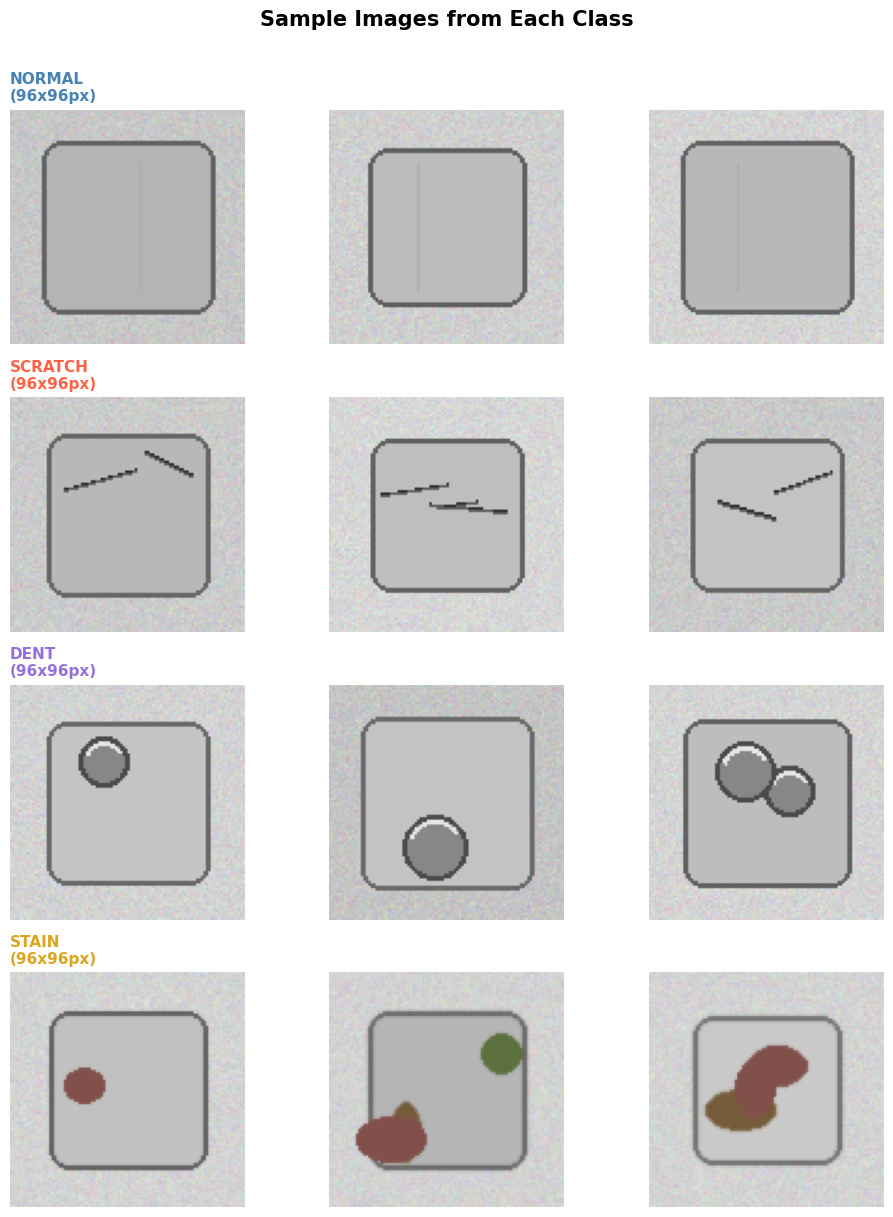

✅ Saved: sample_images_per_class.png


In [8]:
# ── Show sample images from each class (3 samples per class)
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle('Sample Images from Each Class', fontsize=15, fontweight='bold', y=1.01)

label_colors = {'normal': 'steelblue', 'scratch': 'tomato',
                'dent': 'mediumpurple', 'stain': 'goldenrod'}

for row, cls in enumerate(CLASSES):
    img_files = sorted([f for f in os.listdir(f'{BASE_DIR}/{cls}') if f.endswith('.png')])
    sample_files = img_files[:3]   # take first 3

    for col, fname in enumerate(sample_files):
        ax = axes[row][col]
        img = Image.open(f'{BASE_DIR}/{cls}/{fname}')
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{cls.upper()}\n({img.size[0]}x{img.size[1]}px)',
                         fontsize=11, fontweight='bold',
                         color=label_colors[cls], loc='left')
        else:
            ax.set_title('')

plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sample_images_per_class.png")

In [10]:
# Settings
IMG_SIZE = 64        # we'll resize every image to 64x64 pixels
# (original is 96x96, we reduce slightly to speed up training)

# Create a mapping from class name to a number (label)
# The model needs numbers, not text
class_to_label = {cls: i for i, cls in enumerate(CLASSES)}
label_to_class = {i: cls for cls, i in class_to_label.items()}
print("Class → Label mapping:", class_to_label)

# Load all images into Python lists
print("\n📂 Loading images...")
X_raw = []   # will hold image pixel arrays
y_raw = []   # will hold labels (0,1,2,3)

for cls in CLASSES:
    img_files = sorted([f for f in os.listdir(f'{BASE_DIR}/{cls}') if f.endswith('.png')])
    for fname in img_files:
        img_path = f'{BASE_DIR}/{cls}/{fname}'
        img = Image.open(img_path).convert('RGB')   # ensure 3-channel RGB
        img = img.resize((IMG_SIZE, IMG_SIZE))       # resize to 64x64
        X_raw.append(np.array(img))                  # convert to NumPy array
        y_raw.append(class_to_label[cls])            # store label

# Convert lists to NumPy arrays
X = np.array(X_raw, dtype='float32')   # shape: (480, 64, 64, 3)
y = np.array(y_raw)                    # shape: (480,)

print(f"✅ Loaded {len(X)} images")
print(f"   X shape: {X.shape}  → (num_images, height, width, channels)")
print(f"   y shape: {y.shape}")
print(f"   Pixel value range before normalizing: {X.min()} to {X.max()}")

Class → Label mapping: {'normal': 0, 'scratch': 1, 'dent': 2, 'stain': 3}

📂 Loading images...
✅ Loaded 480 images
   X shape: (480, 64, 64, 3)  → (num_images, height, width, channels)
   y shape: (480,)
   Pixel value range before normalizing: 32.0 to 253.0


In [11]:
# Normalize pixel values from [0, 255] → [0.0, 1.0]
# Neural networks train faster and more stably with small numbers
X = X / 255.0
print(f"✅ Normalized: pixel range now {X.min():.2f} to {X.max():.2f}")

✅ Normalized: pixel range now 0.13 to 0.99


In [12]:
# ── Split into Training (70%), Validation (15%), and Test (15%) sets
# First split off the test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
# Then split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
    # 0.176 of 85% ≈ 15% of total
)

print("📦 Dataset Split:")
print(f"  Training   : {len(X_train)} images ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation : {len(X_val)} images ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Testing    : {len(X_test)} images ({len(X_test)/len(X)*100:.0f}%)")

📦 Dataset Split:
  Training   : 336 images (70%)
  Validation : 72 images (15%)
  Testing    : 72 images (15%)


In [13]:
#  Data Augmentation
# Augmentation artificially creates more training variations:
# flipping, rotating, zooming slightly — helps the model generalize better
# We ONLY augment training data, NOT validation or test data

datagen = ImageDataGenerator(
    horizontal_flip=True,    # randomly flip left-right
    vertical_flip=False,     # usually don't flip upside-down for surfaces
    rotation_range=15,       # randomly rotate by up to 15 degrees
    zoom_range=0.1,          # randomly zoom in/out by up to 10%
    width_shift_range=0.1,   # randomly shift left/right by 10%
    height_shift_range=0.1   # randomly shift up/down by 10%
)

# Fit augmentation on training data
datagen.fit(X_train)
print("✅ Data augmentation configured!")
print("   Augmentation applied: horizontal flip, rotation (±15°), zoom (±10%), slight shifts")

✅ Data augmentation configured!
   Augmentation applied: horizontal flip, rotation (±15°), zoom (±10%), slight shifts


---
## 🏗️ Task 4: CNN Model Creation

A CNN (Convolutional Neural Network) works in stages:
1. **Conv layers** detect features like edges, corners, textures
2. **Pooling layers** shrink the image, keeping the important info
3. **Flatten** converts the 2D image map into a 1D list of numbers
4. **Dense layers** combine everything to make the final prediction

In [ ]:
def build_cnn(num_filters_1=32, num_filters_2=64, num_filters_3=128,
              dense_units=128, dropout_rate=0.4, learning_rate=0.001):
    """
    Builds a CNN model. Made as a function so we can change settings easily.
    """
    model = keras.Sequential([

        # ── INPUT: image shape (64, 64, 3) = 64px height, 64px width, 3 color channels (RGB)
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # ══════════════════════════════════
        # BLOCK 1: First Convolution Block
        # ══════════════════════════════════

        # Conv2D: slides a 3x3 filter across the image to detect patterns
        # num_filters_1=32 means 32 different filters (detects 32 different features)
        # padding='same' keeps the output size the same as the input
        layers.Conv2D(num_filters_1, kernel_size=(3,3), activation='relu', padding='same'),
        # Another conv layer in the same block — deepens feature extraction
        layers.Conv2D(num_filters_1, kernel_size=(3,3), activation='relu', padding='same'),
        # BatchNormalization: stabilizes training (makes it faster and more stable)
        layers.BatchNormalization(),
        # MaxPooling2D: shrinks the image by half (64x64 → 32x32)
        # Takes the maximum value in each 2x2 region — keeps the strongest signal
        layers.MaxPooling2D(pool_size=(2,2)),
        # Dropout: randomly turns off 25% of connections to prevent overfitting
        layers.Dropout(0.25),

        # ══════════════════════════════════
        # BLOCK 2: Second Convolution Block
        # ══════════════════════════════════
        layers.Conv2D(num_filters_2, kernel_size=(3,3), activation='relu', padding='same'),
        layers.Conv2D(num_filters_2, kernel_size=(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),   # 32x32 → 16x16
        layers.Dropout(0.25),

        # ══════════════════════════════════
        # BLOCK 3: Third Convolution Block
        # ══════════════════════════════════
        layers.Conv2D(num_filters_3, kernel_size=(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),   # 16x16 → 8x8
        layers.Dropout(0.25),

        # ══════════════════════════════════
        # FLATTEN: Convert 3D (8x8x128) → 1D (8192)
        # ══════════════════════════════════
        layers.Flatten(),

        # ══════════════════════════════════
        # DENSE (Fully Connected) Layers
        # ══════════════════════════════════
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),

        # ══════════════════════════════════
        # OUTPUT LAYER: 4 neurons (one per class)
        # Softmax converts raw scores → probabilities that sum to 1
        # e.g. [0.05, 0.10, 0.80, 0.05] → predicts class 2 (dent)
        # ══════════════════════════════════
        layers.Dense(4, activation='softmax')
    ])

    # ── Compile the model
    # loss='sparse_categorical_crossentropy' → good for multi-class classification
    #   with integer labels (0,1,2,3)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Build and display the baseline model
model = build_cnn()
print("✅ CNN Model built!\n")
model.summary()

---
## 🏋️ Task 5: Model Training and Evaluation

In [ ]:
# ── EarlyStopping: automatically stops training if validation loss
#    doesn't improve for 8 epochs (prevents wasted time + overfitting)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True   # keep the best version of the model
)

# ── ReduceLROnPlateau: if learning stalls, automatically lower the learning rate
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # halve the learning rate
    patience=4,
    min_lr=1e-6
)

print("🏋️ Training the CNN... (this may take 2-5 minutes)")
print("Each epoch processes all training images once.\n")

# ── Train using the augmented data generator
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),   # augmented batches
    epochs=50,
    validation_data=(X_val, y_val),                  # validation: no augmentation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Best epoch: {np.argmax(history.history['val_accuracy'])+1}")
print(f"   Best Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

In [ ]:
# ── Plot Training & Validation Accuracy / Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('CNN Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2, linestyle='--')
axes[1].set_title('CNN Loss Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Behavior (Baseline Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150)
plt.show()
print("✅ Saved: accuracy_loss_curves.png")

In [ ]:
# ── Evaluate on the TEST set (data the model has NEVER seen)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("📊 Final Test Set Performance:")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

# ── Get predictions on test set
y_pred_proba = model.predict(X_test)              # shape: (n, 4) — one probability per class
y_pred = np.argmax(y_pred_proba, axis=1)          # pick the class with highest probability

In [ ]:
# ── Classification Report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

In [ ]:
# ── Confusion Matrix
# Each row = actual class, each column = predicted class
# The diagonal cells (top-left to bottom-right) = correct predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[c.upper() for c in CLASSES],
    yticklabels=[c.upper() for c in CLASSES]
)
plt.title('Confusion Matrix – CNN Baseline Model', fontsize=13, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

# ── Quick interpretation
print("\n📝 Confusion Matrix Interpretation:")
print("   Diagonal values = correct predictions for each class")
for i, cls in enumerate(CLASSES):
    correct = cm[i][i]
    total   = cm[i].sum()
    print(f"   {cls:8s}: {correct}/{total} correctly classified ({correct/total*100:.0f}%)")

In [ ]:
# ── Sample Predictions: show test images with predicted vs actual labels
import random
random.seed(7)

num_samples = 12   # show 12 images (3 rows × 4 columns)
indices = random.sample(range(len(X_test)), num_samples)

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    ax = axes[i]
    ax.imshow(X_test[idx])    # show the image (pixel values are 0-1 after normalization)
    ax.axis('off')

    actual    = label_to_class[y_test[idx]]
    predicted = label_to_class[y_pred[idx]]
    confidence = y_pred_proba[idx][y_pred[idx]] * 100

    correct = (actual == predicted)
    color = 'green' if correct else 'red'
    symbol = '✓' if correct else '✗'

    ax.set_title(
        f"{symbol} Pred: {predicted}\n  Act: {actual} ({confidence:.0f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

# Hide any unused axes
for j in range(len(indices), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Predictions on Test Images  (✓ Correct  |  ✗ Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_outputs.png', dpi=150)
plt.show()
print("✅ Saved: prediction_outputs.png")

---
## 🔬 Hyperparameter Experiments (Bonus)
Let's try 3 variations and compare performance.

In [ ]:
# ── Define 3 experiment configurations
experiments = [
    {'name': 'Exp 1: Baseline',          'filters': (32,64,128),  'dense': 128, 'lr': 0.001, 'dropout': 0.4},
    {'name': 'Exp 2: Larger Filters',    'filters': (64,128,256), 'dense': 256, 'lr': 0.001, 'dropout': 0.4},
    {'name': 'Exp 3: Lower LR',          'filters': (32,64,128),  'dense': 128, 'lr': 0.0005,'dropout': 0.4},
]

exp_results = []

for exp in experiments:
    print(f"\n{'='*55}")
    print(f"🚀 {exp['name']}")
    print(f"{'='*55}")

    m = build_cnn(
        num_filters_1=exp['filters'][0],
        num_filters_2=exp['filters'][1],
        num_filters_3=exp['filters'][2],
        dense_units=exp['dense'],
        dropout_rate=exp['dropout'],
        learning_rate=exp['lr']
    )

    h = m.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        epochs=30,
        validation_data=(X_val, y_val),
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                          restore_best_weights=True)
        ],
        verbose=0
    )

    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    train_acc = max(h.history['val_accuracy'])

    print(f"   Val Acc: {train_acc*100:.2f}%  |  Test Acc: {acc*100:.2f}%")

    exp_results.append({
        'Experiment':        exp['name'],
        'Conv Filters':      str(exp['filters']),
        'Dense Units':       exp['dense'],
        'Learning Rate':     exp['lr'],
        'Best Val Acc (%)':  round(train_acc * 100, 2),
        'Test Acc (%)':      round(acc * 100, 2),
        'Test Loss':         round(loss, 4),
    })

print("\n🎉 All experiments done!")

In [ ]:
# ── Display and save the comparison table
exp_df = pd.DataFrame(exp_results)
print("📊 CNN Experiment Comparison Table:")
display(exp_df)

exp_df.to_csv('cnn_model_comparison_table.csv', index=False)
print("\n✅ Saved: cnn_model_comparison_table.csv")

In [ ]:
# ── Bar chart comparing experiments
plt.figure(figsize=(8, 5))
names = [r['Experiment'] for r in exp_results]
test_accs = [r['Test Acc (%)'] for r in exp_results]
colors = ['steelblue', 'mediumpurple', 'goldenrod']

bars = plt.bar(names, test_accs, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('CNN Experiment Comparison – Test Accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, max(test_accs) + 10)
plt.xticks(rotation=10, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_comparison_chart.png', dpi=150)
plt.show()
print("✅ Saved: cnn_comparison_chart.png")

---
## 💾 Download All Output Files

In [ ]:
from google.colab import files

output_files = [
    'class_distribution.png',
    'sample_images_per_class.png',
    'accuracy_loss_curves.png',
    'confusion_matrix.png',
    'prediction_outputs.png',
    'cnn_model_comparison_table.csv',
    'cnn_comparison_chart.png',
]

for fname in output_files:
    try:
        files.download(fname)
        print(f"⬇️  Downloaded: {fname}")
    except Exception as e:
        print(f"⚠️  {fname}: {e}")

---
## 📚 Task 6: CNN Concept Explanation

### 1. What is Convolution?

Convolution is the core operation in a CNN. Imagine sliding a small **filter** (a tiny grid of numbers, e.g., 3×3) across the entire image. At each position, it multiplies the filter values with the pixel values underneath, sums them all up, and produces one output number. This output is called a **feature map**.

- Different filters detect different features: one might detect **horizontal edges**, another **vertical edges**, another a **circular shape** like a dent.
- With 32 filters in the first layer, the model learns 32 different types of features simultaneously.
- In deeper layers, the CNN combines earlier features into more complex patterns (e.g., "a circular dent with a dark center").

---

### 2. Why is Pooling Used?

After convolution, we get a large feature map. **Max Pooling** shrinks it by looking at small 2×2 regions and keeping only the **maximum value** in each region.

- **Reduces size** → fewer computations, faster training
- **Reduces sensitivity to exact position** → if a scratch moves a few pixels, the model still detects it
- Keeps the most "activated" (strongest) signal from each region

Our model reduces 64×64 → 32×32 → 16×16 → 8×8 through three pooling steps.

---

### 3. Why is ReLU Commonly Used in CNNs?

**ReLU (Rectified Linear Unit)** is defined as: `f(x) = max(0, x)` — it keeps positive values as-is and turns negatives to zero.

Why it's popular:
- **Fast to compute** — just a simple comparison
- **Solves the vanishing gradient problem** — older activations like sigmoid caused gradients to become tiny in deep networks, making learning very slow. ReLU avoids this.
- **Introduces non-linearity** — without this, the CNN could only learn straight-line relationships, no matter how many layers it had
- **Sparse activation** — many neurons output 0, making the network efficient and less prone to overfitting

---

### 4. Why are CNNs Better Than Regular Feed-Forward Networks for Images?

| Feature | Regular Network (Dense) | CNN |
|---|---|---|
| **Parameter count** | Huge — connects every pixel to every neuron | Much smaller — filters are shared across the image |
| **Spatial awareness** | None — treats each pixel independently | Yes — understands 2D structure of images |
| **Translation invariance** | No — if pattern moves, it fails | Yes — detects patterns anywhere in the image |
| **Feature hierarchy** | Flat — no levels of abstraction | Layered — edges → shapes → objects |

A 64×64 RGB image has 64×64×3 = **12,288 input values**. A dense network connecting all inputs to 128 neurons = 1.57 million parameters in the first layer alone. A CNN first layer with 32 filters of size 3×3 = only **32×3×3×3 = 864 parameters** — 1,800× fewer!

---

## 🏭 Task 7: Business Use Case Mapping

### Domain: Manufacturing Quality Control

**The Problem:** In manufacturing plants (automobiles, electronics, consumer goods), products move along assembly lines at high speed. Manual visual inspection is slow, expensive, subjective, and prone to human fatigue.

**The Solution:** A CNN-based defect detection system like the one built in this notebook can be deployed as a **real-time automated quality inspection system**.

**How it works in practice:**
- A high-resolution camera captures images of each product as it passes
- The CNN classifies the surface into: `normal`, `scratch`, `dent`, or `stain`
- Defective products are automatically flagged and diverted off the line
- Results are logged for quality analytics

**Business Benefits:**
- 🚀 **Speed** — inspects hundreds of units per minute vs. 1 per few seconds (human)
- 🎯 **Consistency** — same accuracy at 6 AM and 6 PM, no fatigue
- 💰 **Cost savings** — reduces returns, warranty claims, and rework costs
- 📊 **Data insights** — tracks defect trends over time for root-cause analysis
- 🔧 **Predictive maintenance** — if dent rates spike, it may indicate a machine tool is worn out

**Real examples:** Foxconn (iPhone assembly), BMW (car body inspection), Samsung (display panel QC)

---
*✅ End of Part 2 Notebook*